# M6.2 — Полиграф на LangGraph + HIL

Агент-полиграф проверяет факты из `questions.csv` и возвращает `True`/`False`.

Граф: `react_agent` → `judge` (структурированный вывод с полем `confidence`) → `human_check` (узел с `interrupt`, срабатывает только при низкой уверенности).

Порог: 22/25 правильных ответов. Ответы в колонке `answers` должны быть Python `bool`.

In [2]:
import os
from getpass import getpass
from pathlib import Path
from typing_extensions import TypedDict, Literal

import pandas as pd
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_classic.agents import load_tools

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt

load_dotenv("../.env")

True

In [2]:
course_api_key = os.getenv('OPENAI_API_KEY') or getpass(prompt='Введите ваш ключ курса: ')
os.environ['OPENAI_API_KEY'] = course_api_key

if not os.getenv('SERPAPI_API_KEY'):
    os.environ['SERPAPI_API_KEY'] = getpass(prompt='Введите ваш SerpAPI ключ: ')

llm = ChatOpenAI(
    api_key=course_api_key,
    model='gpt-4o-mini',
    base_url='https://api.vsellm.ru/',
    temperature=0.0,
)

## Состояние графа и схема вердикта

In [3]:
class AgentState(TypedDict):
    statement: str
    raw: str
    answer: bool
    confidence: Literal['low', 'high']
    reason: str


class Verdict(BaseModel):
    answer: bool = Field(description='True если утверждение верно, False если ложно')
    confidence: Literal['low', 'high'] = Field(
        description="'high' если уверены на 95%+, иначе 'low'"
    )
    reason: str = Field(description='Краткое объяснение, 1-2 предложения')

## Узлы графа

In [4]:
tools = load_tools(['llm-math', 'serpapi'], llm=llm)

REACT_PROMPT = (
    'Ты — фактчекер. Определи, истинно или ложно данное утверждение. '
    'Пользуйся поиском (serpapi) для фактов и калькулятором (llm-math) для арифметики. '
    'В математических утверждениях вида sin(90), cos(180) и т.п. бытовые углы трактуются в ГРАДУСАХ, '
    'если явно не сказано иначе (sin 90° = 1, cos 90° = 0). '
    'В конце дай развёрнутый ответ с обоснованием.'
)

react_agent = create_react_agent(llm, tools, prompt=REACT_PROMPT)


def react_node(state: AgentState) -> dict:
    result = react_agent.invoke({'messages': [HumanMessage(content=state['statement'])]})
    last = result['messages'][-1].content
    return {'raw': last}


JUDGE_PROMPT = (
    'На основе анализа ниже сформулируй финальный вердикт: True или False. '
    'Поставь confidence="high" только если уверенность ≥ 95%, иначе "low".'
)


def judge_node(state: AgentState) -> dict:
    verdict = llm.with_structured_output(Verdict).invoke([
        SystemMessage(content=JUDGE_PROMPT),
        HumanMessage(content=f"Утверждение: {state['statement']}\n\nАнализ агента:\n{state['raw']}"),
    ])
    return {
        'answer': verdict.answer,
        'confidence': verdict.confidence,
        'reason': verdict.reason,
    }


def human_check_node(state: AgentState):
    if state['confidence'] == 'high':
        return Command(goto=END)

    prompt_text = (
        f"Утверждение: {state['statement']}\n"
        f"Вердикт агента: {state['answer']} ({state['confidence']})\n"
        f"Обоснование: {state['reason']}\n"
        "Введите 'ok' чтобы подтвердить, либо 'true' / 'false' чтобы переопределить: "
    )
    feedback = interrupt(prompt_text)
    fb = (feedback or '').strip().lower()
    if fb in ('true', 'истина', '1', 'да'):
        return Command(goto=END, update={'answer': True})
    if fb in ('false', 'ложь', '0', 'нет'):
        return Command(goto=END, update={'answer': False})
    return Command(goto=END)

/var/folders/1v/2njvtrl903s020_gk0tw647c0000gn/T/ipykernel_48801/612301309.py:11: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_agent = create_react_agent(llm, tools, prompt=REACT_PROMPT)


## Сборка графа

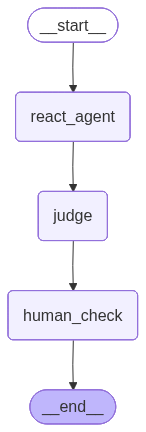

In [5]:
builder = StateGraph(AgentState)
builder.add_node('react_agent', react_node)
builder.add_node('judge', judge_node)
builder.add_node('human_check', human_check_node)

builder.add_edge(START, 'react_agent')
builder.add_edge('react_agent', 'judge')
builder.add_edge('judge', 'human_check')

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## Прогон по датасету

In [3]:
HERE = Path.cwd()
CSV_IN = HERE / 'questions.csv'
CSV_OUT = HERE.parent / 'submissions' / 'm6_polygraph_solution.csv'

df = pd.read_csv(CSV_IN)
df.head()

,texts,answers
0,Человек использует только 10% своего мозга.,?
1,Кошки и собаки видят мир в черно-белых тонах.,?
2,Дейтерий - это изотоп водорода.,?
3,Пчёлы не могут видеть красный цвет.,?
4,Нейтроны - это элементарные частицы с отрицате...,?


In [7]:
answers: list[bool] = []

for i, statement in enumerate(df['texts']):
    print(f'\n[{i+1}/{len(df)}] {statement}')
    config = {'configurable': {'thread_id': f'q{i}'}}
    try:
        result = graph.invoke({'statement': statement}, config)
        while '__interrupt__' in result:
            intr = result['__interrupt__'][0]
            user_input = input(intr.value)
            result = graph.invoke(Command(resume=user_input), config)
        verdict = bool(result['answer'])
        print(f'  -> {verdict} ({result.get("confidence")})')
    except Exception as e:
        print(f'  ERROR: {e} — defaulting to True')
        verdict = True
    answers.append(verdict)

df['answers'] = answers
df.head(25)


[1/25] Человек использует только 10% своего мозга.
  -> False (high)

[2/25] Кошки и собаки видят мир в черно-белых тонах.
  -> False (high)

[3/25] Дейтерий - это изотоп водорода.
  -> True (high)

[4/25] Пчёлы не могут видеть красный цвет.
  -> True (high)

[5/25] Нейтроны - это элементарные частицы с отрицательным зарядом.
  -> False (high)

[6/25] Земля обращается вокруг Солнца по эллиптической орбите.
  -> True (high)

[7/25] Период полураспада урана-238 составляет 4,5 миллиарда лет.
  -> True (high)

[8/25] "Дельта" в науке обозначает изменение квантового состояния.
  -> False (high)

[9/25] Антибиотики эффективны против вирусов.
  -> False (high)

[10/25] Все диамагнетики являются суперпроводниками.
  -> False (high)

[11/25] Коровы могут подниматься вверх по лестнице, но не могут спускаться.
  -> True (high)

[12/25] Геллаград - самая холодная планета в солнечной системе.
  -> False (high)

[13/25] Эволюция - это процесс, который отвечает за биологическое разнообразие на всех 

ValueError: I/O operation on closed file

In [15]:
answers.append(False)

In [16]:
df['answers'] = answers
df.head(25)

,texts,answers
0,Человек использует только 10% своего мозга.,False
1,Кошки и собаки видят мир в черно-белых тонах.,False
2,Дейтерий - это изотоп водорода.,True
3,Пчёлы не могут видеть красный цвет.,True
4,Нейтроны - это элементарные частицы с отрицате...,False
5,Земля обращается вокруг Солнца по эллиптическо...,True
6,"Период полураспада урана-238 составляет 4,5 ми...",True
7,"""Дельта"" в науке обозначает изменение квантово...",False
8,Антибиотики эффективны против вирусов.,False
9,Все диамагнетики являются суперпроводниками.,False


In [18]:
CSV_OUT.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(CSV_OUT, index=False)
CSV_OUT

PosixPath('/Users/khodosevichleo/Desktop/Weiterbildung/LLM/submissions/m6_polygraph_solution.csv')

In [7]:
import pandas as pd

df = pd.DataFrame({
    "texts": [
        "Человек использует только 10% своего мозга.",
        "Кошки и собаки видят мир в черно-белых тонах.",
        "Дейтерий - это изотоп водорода.",
        "Пчёлы не могут видеть красный цвет.",
        "Нейтроны - это элементарные частицы с отрицательным зарядом.",
        "Земля обращается вокруг Солнца по эллиптической орбите.",
        "Период полураспада урана-238 составляет 4,5 миллиарда лет.",
        "\"Дельта\" в науке обозначает изменение квантового состояния.",
        "Антибиотики эффективны против вирусов.",
        "Все диамагнетики являются суперпроводниками.",
        "Коровы могут подниматься вверх по лестнице, но не могут спускаться.",
        "Геллаград - самая холодная планета в солнечной системе.",
        "Эволюция - это процесс, который отвечает за биологическое разнообразие на всех уровнях: от королевств до видов и даже внутривидового разнообразия.",
        "Климатическое изменение вызывает увеличение средней температуры планеты.",
        "Задержания в росте какого-либо растения могут быть вызваны недостатком углекислого газа.",
        "В людских генах содержатся вирусные элементы.",
        "Все птицы - яйцекладущие.",
        "Боль ключевой кости обычно вызывается болезнью Паркинсона.",
        "Непрямые эффекты ионизирующей радиации могут вызвать генетические изменения.",
        "Апельсины должны быть оранжевыми для созревания.",
        "sin(90) − cos(90) = 1",
        "2500 * 5 - 5 = 0",
        "Курс который вы сейчас проходите размещён на Stepik.",
        "Одного из преподавателей этого курса зовут Валера Бабушкин.",
        "Пушкин родился в 1837 году в Нью-Йорке."
    ],
    "answers": [
        False,
        False,
        True,
        True,
        False,
        True,
        True,
        False,
        False,
        False,
        True,
        False,
        True,
        True,
        True,
        True,
        True,
        False,
        True,
        False,
        True,
        False,
        True,
        False,
        False
    ]
})

print(df)

                                                texts  answers
0         Человек использует только 10% своего мозга.    False
1       Кошки и собаки видят мир в черно-белых тонах.    False
2                     Дейтерий - это изотоп водорода.     True
3                 Пчёлы не могут видеть красный цвет.     True
4   Нейтроны - это элементарные частицы с отрицате...    False
5   Земля обращается вокруг Солнца по эллиптическо...     True
6   Период полураспада урана-238 составляет 4,5 ми...     True
7   "Дельта" в науке обозначает изменение квантово...    False
8              Антибиотики эффективны против вирусов.    False
9        Все диамагнетики являются суперпроводниками.    False
10  Коровы могут подниматься вверх по лестнице, но...     True
11  Геллаград - самая холодная планета в солнечной...    False
12  Эволюция - это процесс, который отвечает за би...     True
13  Климатическое изменение вызывает увеличение ср...     True
14  Задержания в росте какого-либо растения могут ...  

In [8]:
CSV_OUT.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(CSV_OUT, index=False)
CSV_OUT

PosixPath('/Users/khodosevichleo/Desktop/Weiterbildung/LLM/submissions/m6_polygraph_solution.csv')